In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [5]:
df = pd.read_csv("jbronyah_project_summary.csv", sep=";")
df.columns = ['project','commit','author','time','message']
df['Month'] = pd.to_datetime(df['time'], unit='s').dt.strftime('%Y-%m')
df.head()

,project,commit,author,time,message,Month
0,pecanproject_pecan,0000896d56a7024d7019a01bc671771176ed3800,Betsy Cowdery <emcowdery@gmail.com>,1478089294,Adding optional argument var.ids so that only ...,2016-11
1,pecanproject_pecan,00016bb4e39dabf9cb86675c0624759c96c8096e,DongchenZ <zhangdc@bu.edu>,1637338734,"add "",""",2021-11
2,pecanproject_pecan,000309f6c1f5a9c3109a25e6b5689dc0b1fdf7d0,Rob Kooper <kooper@illinois.edu>,1513177654,update CHANGELOG,2017-12
3,pecanproject_pecan,000524866d3892b4508ddcbfd4f658226e91701c,Michael Dietze <dietze@bu.edu>,1534264969,Merge pull request #2044 from infotroph/soilpa...,2018-08
4,pecanproject_pecan,0007f980acaae33dcab95834c205f75b21ed7e0a,David LeBauer <dlebauer@gmail.com>,1432070953,removed obsolete functions from models/biocro ...,2015-05


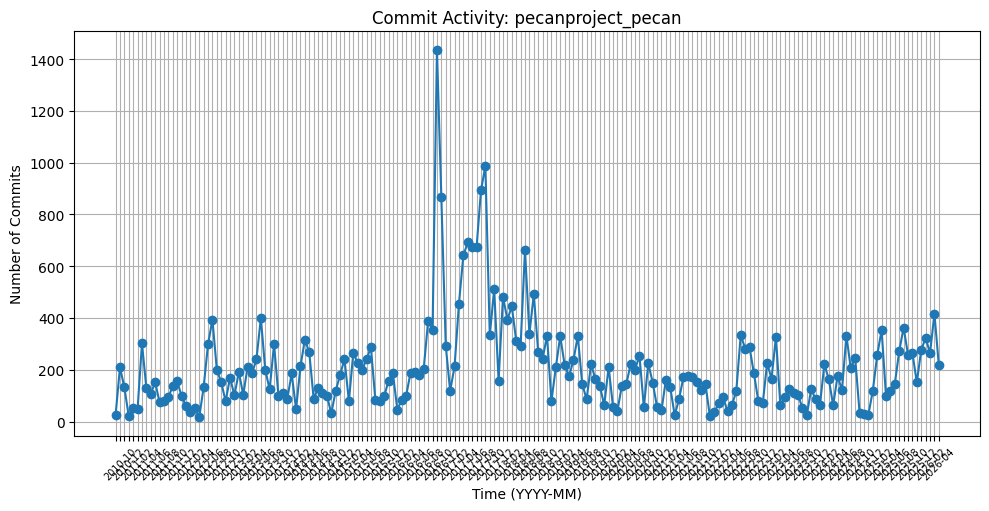

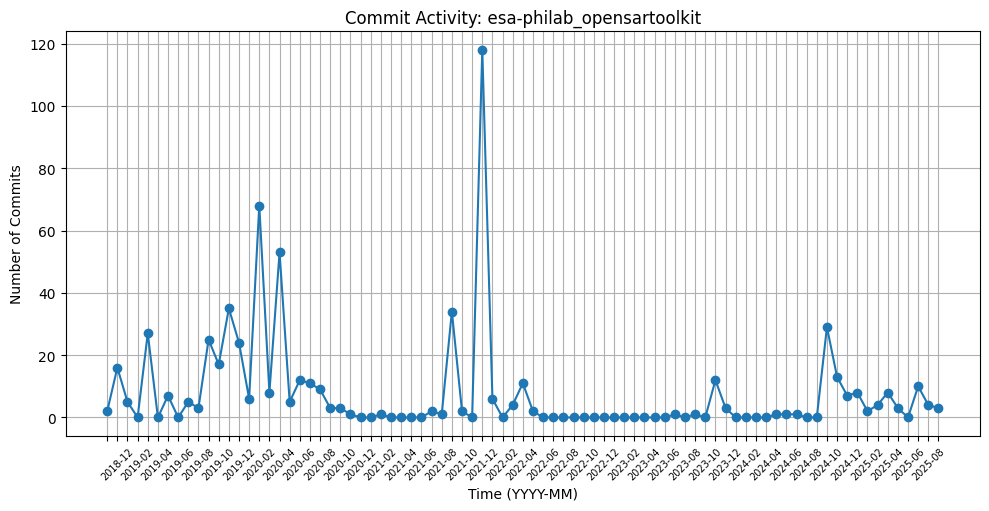

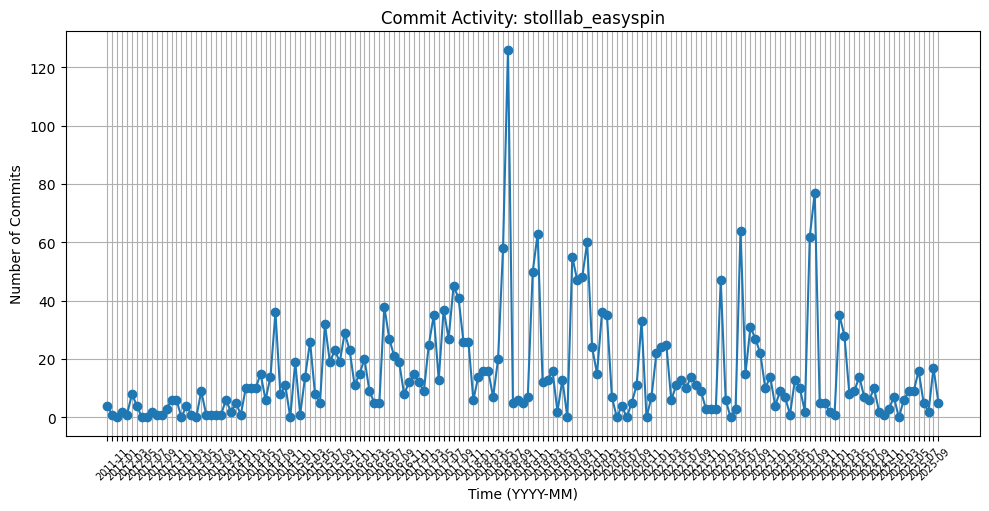

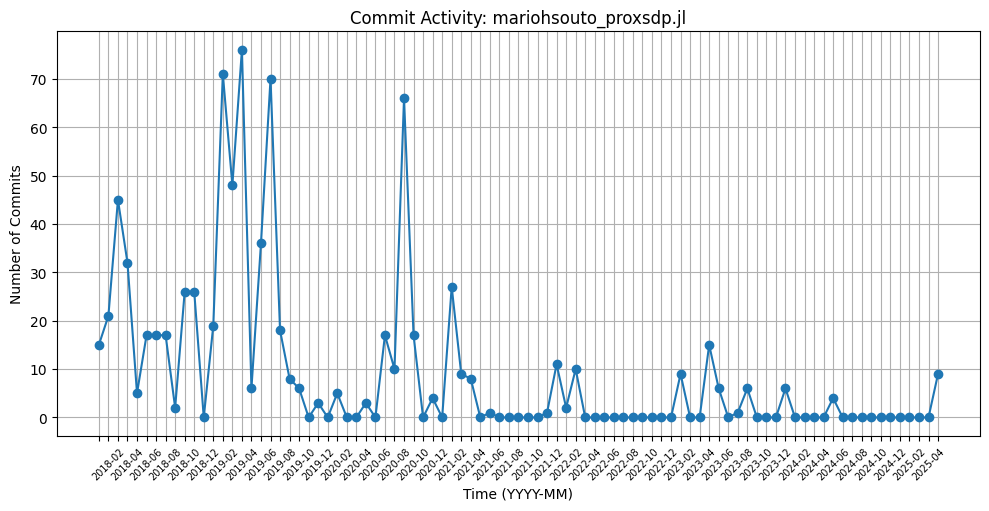

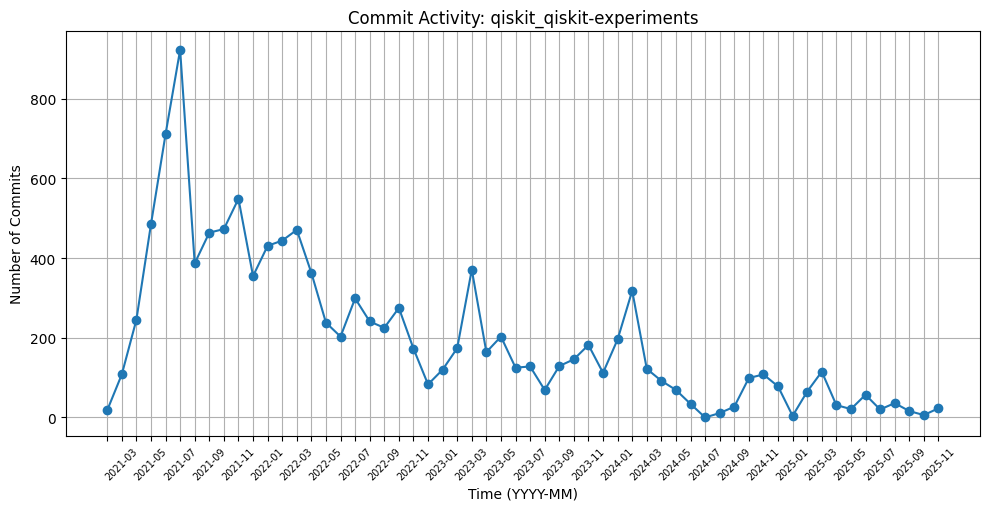

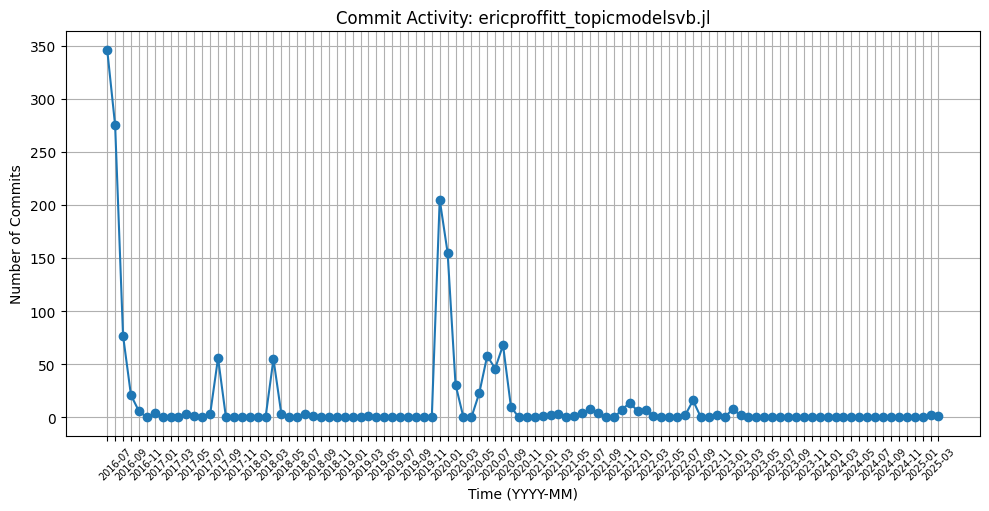

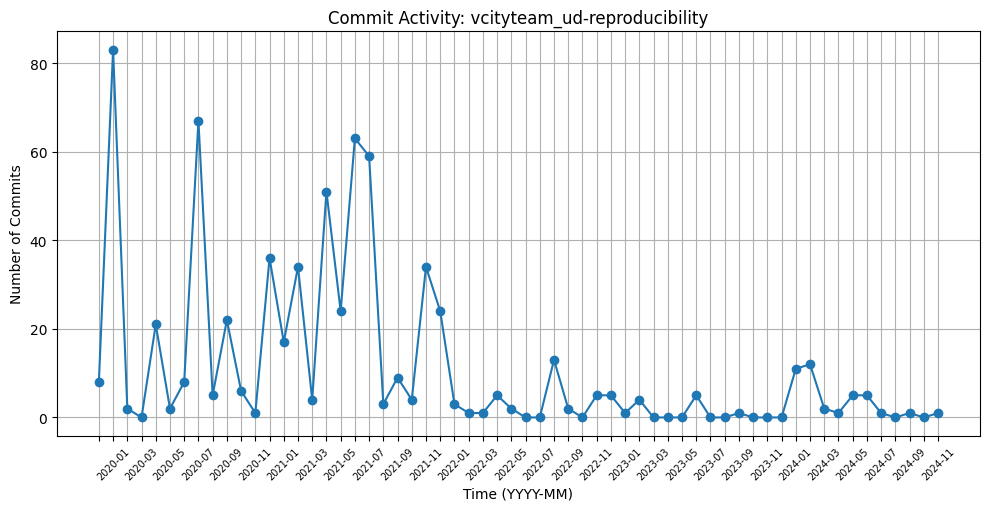

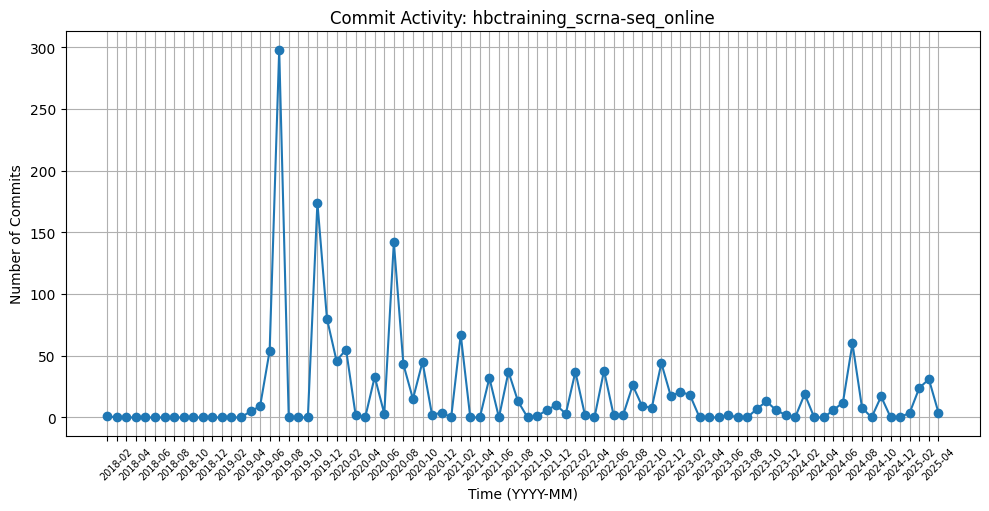

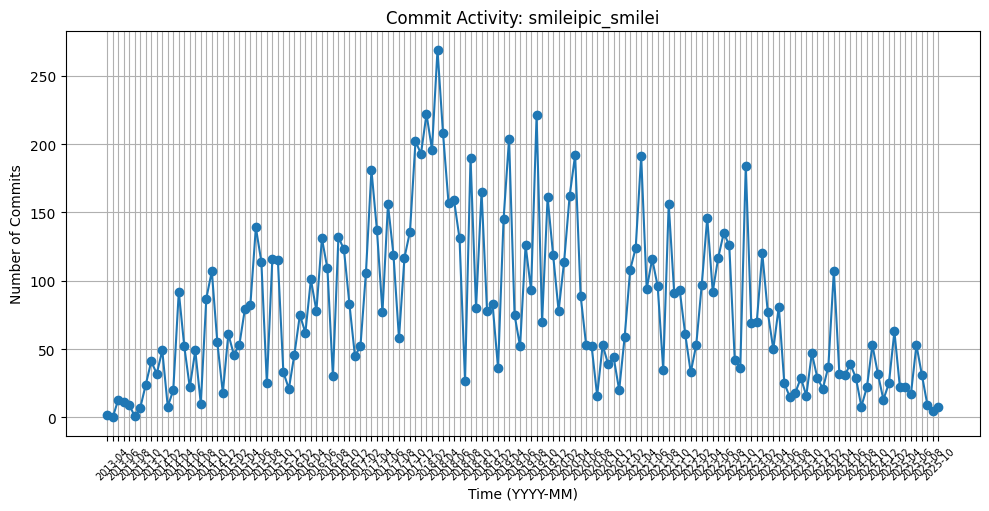

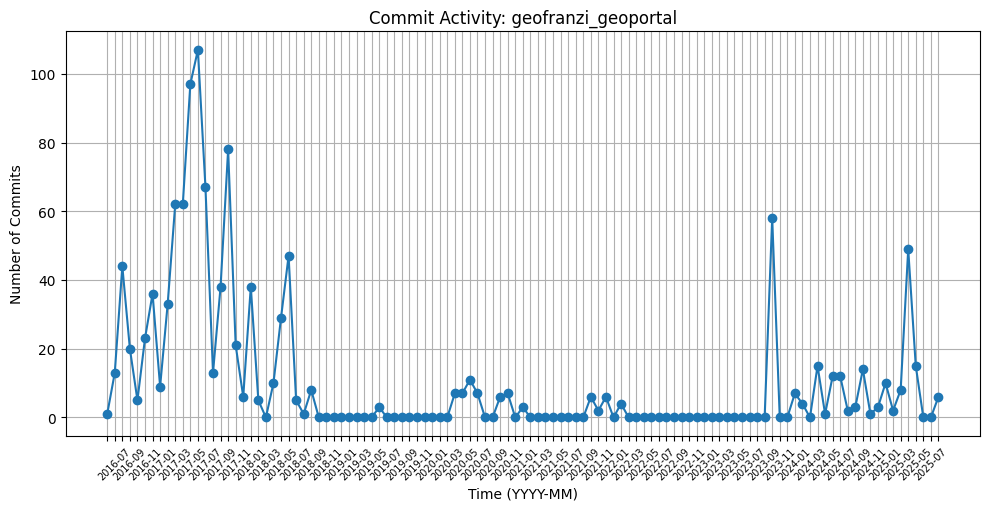

Updated files:
1. jbronyah_commits_timeseries.csv
2. jbronyah_project_stats.csv (updated to all 13 columns)


,project,#commits,#authors,From,To,#stars,#forks,LastGHCommitDate,"LongestGapStart (YYYY-MM),","LongestGapEnd (YYYY-MM),",LongestGapLength,NumCommitsAfterLastGap,pattern
0,ericproffitt_topicmodelsvb.jl,1542,11,1466824003,1741617121,84,9,2025/02/09,2023-03,2025-01,23,3,declining
1,esa-philab_opensartoolkit,637,31,1542903465,1758635026,248,60,2026/02/04,2022-06,2023-06,13,111,declining
2,geofranzi_geoportal,1169,14,1467280640,1756391053,0,0,2025/05/12,2022-03,2023-09,19,222,declining
3,hbctraining_scrna-seq_online,1619,16,1514765279,1744731382,672,209,2026/08/20,2018-02,2019-03,14,1618,declining
4,mariohsouto_proxsdp.jl,831,20,1515506544,1748191005,97,13,2025/05/25,2022-04,2023-01,10,56,declining
5,pecanproject_pecan,38951,454,1283468974,1776459632,246,321,2026/09/25,None,None,0,0,sporadic
6,qiskit_qiskit-experiments,11635,145,1614191172,1762367916,197,139,2026/09/09,2024-07,2024-07,1,717,declining
7,smileipic_smilei,11931,212,1364546318,1761655373,449,157,2026/09/14,2013-04,2013-04,1,11929,sporadic
8,stolllab_easyspin,2542,41,1318928290,1759430732,66,29,2026/09/28,2012-05,2012-06,2,2522,sporadic
9,vcityteam_ud-reproducibility,674,26,1576158853,1732201063,2,2,2024/11/21,2023-03,2023-05,3,45,declining


In [6]:
netid = 'jbronyah'

projects = [
    'pecanproject_pecan',
    'esa-philab_opensartoolkit',
    'stolllab_easyspin',
    'mariohsouto_proxsdp.jl',
    'qiskit_qiskit-experiments',
    'ericproffitt_topicmodelsvb.jl',
    'vcityteam_ud-reproducibility',
    'hbctraining_scrna-seq_online',
    'smileipic_smilei',
    'geofranzi_geoportal',
]

all_timeseries = []
gap_results = []

for prj in projects:
  # Filter project and aggregate monthly counts
  df1 = df[df['project'] == prj]
  if df1.empty:
    continue
  df2 = df1.groupby('Month').size().reset_index(name='Commits')
  monthly_counts = df2
  monthly_counts['time'] = pd.to_datetime(monthly_counts['Month'])
  full_date_range = pd.DataFrame({
      'time': pd.date_range(
          start=monthly_counts['time'].min(),
          end=monthly_counts['time'].max(),
          freq='MS',
      )
  })
  monthly_counts = pd.merge(
      full_date_range, monthly_counts, on='time', how='left'
  ).fillna(0)
  monthly_counts['Month'] = monthly_counts['time'].dt.strftime('%Y-%m')
  monthly_counts['project'] = prj

  # -----------------------------------------------------------------
  # Collect & save timeseries data
  # -----------------------------------------------------------------
  all_timeseries.append(monthly_counts[['project', 'Month', 'Commits']])
  monthly_counts[['project', 'Month', 'Commits']].to_csv(
      f'{netid}_commits_timeseries_{prj}.csv', sep=';', index=False
  )

  # -----------------------------------------------------------------
  # Plotting
  # -----------------------------------------------------------------
  plt.figure(figsize=(10, 5))
  plt.plot(
      monthly_counts['Month'],
      monthly_counts['Commits'],
      marker='o',
      linestyle='-',
  )
  plt.xlabel('Time (YYYY-MM)')
  plt.ylabel('Number of Commits')
  plt.title('Commit Activity: ' + prj)
  plt.grid(True)
  plt.tight_layout()
  ax = plt.gca()
  for label in ax.xaxis.get_ticklabels()[::2]:
    label.set_visible(False)
  plt.xticks(rotation=45, fontsize=7)
  plt.savefig(f'{netid}_timeseries_' + prj + '.png', dpi=600)
  plt.show()
  plt.close()

  # -----------------------------------------------------------------
  # Analyze Inactivity Gaps
  # -----------------------------------------------------------------
  zero_runs = []
  start_idx = None
  cur_len = 0

  for i, row in monthly_counts.iterrows():
    if row['Commits'] == 0:
      if start_idx is None:
        start_idx = i
      cur_len += 1
    else:
      if start_idx is not None:
        zero_runs.append((start_idx, i - 1, cur_len))
        start_idx = None
        cur_len = 0
  if start_idx is not None:
    zero_runs.append((start_idx, len(monthly_counts) - 1, cur_len))

  if zero_runs:
    longest = max(zero_runs, key=lambda x: x[2])
    gap_start_idx, gap_end_idx, gap_len = longest
    gap_start = monthly_counts.loc[gap_start_idx, 'Month']
    gap_end = monthly_counts.loc[gap_end_idx, 'Month']
    commits_after = (
        int(monthly_counts.loc[gap_end_idx + 1 :, 'Commits'].sum())
        if gap_end_idx + 1 < len(monthly_counts)
        else 0
    )
  else:
    gap_start = 'None'
    gap_end = 'None'
    gap_len = 0
    commits_after = 0

  # Activity pattern classification heuristic
  mid = len(monthly_counts) // 2
  first_half = monthly_counts.loc[:mid, 'Commits'].sum()
  second_half = monthly_counts.loc[mid:, 'Commits'].sum()
  last_6_months = monthly_counts.loc[
      max(0, len(monthly_counts) - 6) :, 'Commits'
  ].sum()

  if last_6_months == 0 and commits_after < 5:
    pattern = 'dormant'
  elif second_half < first_half * 0.5:
    pattern = 'declining'
  elif second_half > first_half * 1.5:
    pattern = 'increasing'
  else:
    pattern = 'sporadic'

  gap_results.append({
      'project': prj,
      'LongestGapStart (YYYY-MM), ': gap_start,
      'LongestGapEnd (YYYY-MM),': gap_end,
      'LongestGapLength': gap_len,
      'NumCommitsAfterLastGap': commits_after,
      'pattern': pattern,
  })

# =====================================================================
# Export Consolidated Timeseries CSV
# =====================================================================
df_all_timeseries = pd.concat(all_timeseries, ignore_index=True)
df_all_timeseries.to_csv(f'{netid}_commits_timeseries.csv', sep=';', index=False)

# =====================================================================
# Update jbronyah_project_stats.csv With Gap Results
# =====================================================================
stats_filename = f'{netid}_project_stats.csv'
existing_stats = pd.read_csv(stats_filename, sep=';')

# Keep base 8 columns from Part 1
base_cols = [
    'project',
    '#commits',
    '#authors',
    'From',
    'To',
    '#stars',
    '#forks',
    'LastGHCommitDate',
]
existing_stats = existing_stats[
    [c for c in base_cols if c in existing_stats.columns]
]

# Merge Part 2 gap/pattern columns 
df_gaps = pd.DataFrame(gap_results)
updated_stats = existing_stats.merge(df_gaps, on='project', how='left')

# Save updated CSV
updated_stats.to_csv(stats_filename, sep=';', index=False)

print('Updated files:')
print(f'1. {netid}_commits_timeseries.csv')
print(f'2. {netid}_project_stats.csv (updated to all 13 columns)')
display(updated_stats)